Introduction to Data Science (A1 - A5)


**A1. Data Wrangling**

In [1]:
import pandas as pd
students = pd.read_csv('Student_List_A2.csv')
print("Columns:")
print(students.columns)

Columns:
Index(['StudentID', 'Age', 'StudyTimeWeekly', 'Absences', 'ParentalSupport',
       'GPA', 'GradeClass'],
      dtype='object')


In [2]:
print(students.dtypes)

StudentID            int64
Age                  int64
StudyTimeWeekly    float64
Absences             int64
ParentalSupport      int64
GPA                float64
GradeClass           int64
dtype: object


Before replacement, the data type of GradeClass is int64.

In [3]:
# Replace numerical grade classification in GradeClass with letter grades
students_replace = students.copy()
students_replace.loc[students_replace['GradeClass'] == 0, 'GradeClass'] = 'A'
students_replace.loc[students_replace['GradeClass'] == 1, 'GradeClass'] = 'B'
students_replace.loc[students_replace['GradeClass'] == 2, 'GradeClass'] = 'C'
students_replace.loc[students_replace['GradeClass'] == 3, 'GradeClass'] = 'D'
students_replace.loc[students_replace['GradeClass'] == 4, 'GradeClass'] = 'F'
students_replace.sample(10)

C:\Users\eliza\AppData\Local\Temp\ipykernel_47692\1727527598.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'A' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  students_replace.loc[students_replace['GradeClass'] == 0, 'GradeClass'] = 'A'


,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
1660,2662,17,11.684496,29,1,0.223431,F
1183,2185,18,16.253861,19,3,2.131447,D
1061,2063,17,12.582352,17,3,1.841908,F
1326,2328,15,19.444594,29,4,1.584479,F
37,1039,15,2.949078,3,1,3.018906,B
1485,2487,17,0.712243,24,2,0.972248,F
409,1411,17,8.348966,8,3,2.427615,D
1170,2172,17,0.656510,8,4,2.380667,D
395,1397,18,2.962016,18,2,1.089441,F
155,1157,17,18.843709,28,0,0.503067,F


In [4]:
# Make sure GradeClass datatype remains int64.
students.dtypes

StudentID            int64
Age                  int64
StudyTimeWeekly    float64
Absences             int64
ParentalSupport      int64
GPA                float64
GradeClass           int64
dtype: object

--- A1 Task 1 ---

In [5]:
# Missing values count of the Columns 
print("Missing values before imputation:")
print(students.isnull().sum())

Missing values before imputation:
StudentID           0
Age                 0
StudyTimeWeekly    21
Absences            0
ParentalSupport     0
GPA                 0
GradeClass          0
dtype: int64


There are 21 missing values in the StudyTimeWeekly Column.

In [6]:
# Print out rows with missing values
students[students['StudyTimeWeekly'].isnull()]

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
19,1021,16,NaN,2,3,2.778411,2
23,1025,18,NaN,15,2,1.505156,4
105,1107,16,NaN,18,0,0.842296,4
126,1128,15,NaN,10,1,2.819922,2
260,1262,16,NaN,20,1,1.265678,4
388,1390,15,NaN,16,3,1.848866,4
444,1446,17,NaN,29,4,0.869123,4
492,1494,16,NaN,25,1,0.567237,4
558,1560,16,NaN,5,3,3.366930,1
599,1601,15,NaN,7,1,2.446157,3


Missing values are replaced with the median of the feature because it is not sensitive to outliers.

In [7]:

# Replace missing value in Column['StudyTimeWeekly'] with its median
median = students['StudyTimeWeekly'].median()
students.loc[students['StudyTimeWeekly'].isnull(), 'StudyTimeWeekly'] = median

# Count of missing values after imputation
print("Missing values after imputation: ")
print(students.isnull().sum())

Missing values after imputation: 
StudentID          0
Age                0
StudyTimeWeekly    0
Absences           0
ParentalSupport    0
GPA                0
GradeClass         0
dtype: int64


Since all the missing values are replaced using the median, no missing values exist

--- A1 Task 2 ---

In [8]:
# Ensuring the data in the Absences column is int64
print("Data type of the values in Absence:")
print(students['Absences'].dtypes)
print()
# Get the statistical description on 'Absences' column
print("Absence Column Description:")
print(students['Absences'].describe())

# List out the values of Absences to see the values.
students['Absences'].value_counts()

Data type of the values in Absence:
int64

Absence Column Description:
count    2100.000000
mean       14.709048
std        11.153253
min      -122.000000
25%         7.000000
50%        15.000000
75%        22.000000
max       320.000000
Name: Absences, dtype: float64


Absences
 12     85
 13     82
 20     82
 19     82
 25     81
 5      77
 23     77
 8      77
 7      75
 15     75
 14     74
 18     73
 6      72
 1      72
 27     71
 3      71
 17     71
 24     70
 16     69
 21     68
 26     68
 22     68
 11     65
 29     64
 2      61
 0      56
 4      55
 10     55
 9      54
 28     48
 320     1
-122     1
Name: count, dtype: int64

The range identified from the value counts is 0-29, excluding outliers, which are -122 and 320.

In [9]:
# Absences that smaller than 0 or more than 30 ( rounded from range)
students[(students['Absences'] < 0) | (students['Absences'] > 30)]

,StudentID,Age,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
112,1114,16,16.849282,320,1,1.919956,4
1001,2003,15,0.806505,-122,3,3.201710,1


Data Quality Issue:
There exists an extreme outlier and a negative number in the 'Absence' column. The Absences column likely represents a count of days missed in a semester, which has a maximum of around 30-120 days; values larger than them is physically impossible.
The extremely large absence value (320) is identified as an outlier because it lies far outside the normal range of student attendance and may result from typing mistakes. As for the negative value, it is invalid because a student cannot have fewer than zero absences, so this is faulty or irregular data.
These data quality issues may happen due to incorrect manual entry, such as an extra digit being entered.

In [10]:
# Remove both the rows that contain faulty data and outliers.
students = students[students['Absences'] >= 0]
students = students[students['Absences'] <= 30]

# Print out the statistics of the column to ensure they are removed successfully.
students['Absences'].describe()

count    2098.000000
mean       14.628694
std         8.434995
min         0.000000
25%         7.000000
50%        15.000000
75%        22.000000
max        29.000000
Name: Absences, dtype: float64

--- A1 Task 3 ---

In [11]:
# List out the number of each grade class
print(students['GradeClass'].value_counts() )

# Create a table that counts the number of student in each GPA range
print()
print("Expected Number of Students for each grade class:")
expected_GPA_number = pd.DataFrame({
    'GPA range' : ['>=3.5', '3.0-3.5', '2.5-3.0','2.0-2.5', '<2.0'],
    'Grade Class' : [0,1,2,3,4]
})
expected_GPA_number.loc[expected_GPA_number['GPA range'] == '>=3.5', 'Number'] = (students['GPA']>=3.5).sum()
expected_GPA_number.loc[expected_GPA_number['GPA range'] == '3.0-3.5', 'Number'] = ((students['GPA'] >=3.0) & (students['GPA']<3.5)).sum()
expected_GPA_number.loc[expected_GPA_number['GPA range'] == '2.5-3.0', 'Number'] = ((students['GPA'] >=2.5) & (students['GPA']<3.0)).sum()
expected_GPA_number.loc[expected_GPA_number['GPA range'] == '2.0-2.5', 'Number'] = ((students['GPA'] >=2.0) & (students['GPA']<2.5)).sum()
expected_GPA_number.loc[expected_GPA_number['GPA range'] == '<2.0', 'Number'] = (students['GPA']<2.0).sum()
expected_GPA_number

GradeClass
4    1064
2     352
3     344
1     241
0      97
Name: count, dtype: int64

Expected Number of Students for each grade class:


,GPA range,Grade Class,Number
0,>=3.5,0,61.0
1,3.0-3.5,1,204.0
2,2.5-3.0,2,339.0
3,2.0-2.5,3,369.0
4,<2.0,4,1125.0


The number of students in each GPA range and the grade class from the data are not consistent, displaying an inconsistency in the data.

In [12]:
# Create a 'ExpectedGradeClass' column to analyse inconsistency
students.loc[students['GPA'] >= 3.5, 'ExpectedGradeClass'] = 0
students.loc[(students['GPA'] >= 3.0) & (students['GPA'] < 3.5), 'ExpectedGradeClass'] = 1
students.loc[(students['GPA'] >= 2.5) & (students['GPA'] < 3.0), 'ExpectedGradeClass'] = 2
students.loc[(students['GPA'] >= 2.0) & (students['GPA'] < 2.5), 'ExpectedGradeClass'] = 3
students.loc[students['GPA'] < 2.0, 'ExpectedGradeClass'] = 4

# List a few examples that show grade class and GPA inconsistency
mismatch = students[students['GradeClass'] != students['ExpectedGradeClass']]
print("Number of inconsistent rows:", len(mismatch))
print("Examples of mismatched rows: ")
mismatch[['StudentID', 'GPA', 'GradeClass', 'ExpectedGradeClass']].head()

Number of inconsistent rows: 100
Examples of mismatched rows: 


,StudentID,GPA,GradeClass,ExpectedGradeClass
2000,3182,1.844056,1,4.0
2001,3183,1.305585,2,4.0
2002,3189,2.459805,1,3.0
2003,3193,0.818126,2,4.0
2004,3195,1.174610,0,4.0


I decided to trust the GPA column because GradeClass should be classified based on the GPA column and cut-offs. Therefore, the GradeClass column is identified as an inconsistent column and will be updated based on the GPA cut-offs.

In [13]:
# Fix the inconsistency in GradeClass
students.loc[students['GPA'] >= 3.5, 'GradeClass'] = 0
students.loc[(students['GPA'] < 3.5) & (students['GPA'] >= 3.0), 'GradeClass'] = 1
students.loc[(students['GPA'] < 3.0) & (students['GPA'] >= 2.5), 'GradeClass'] = 2
students.loc[(students['GPA'] < 2.5) & (students['GPA'] >= 2.0), 'GradeClass'] = 3
students.loc[students['GPA'] < 2.0, 'GradeClass'] = 4

print(students['GradeClass'].value_counts())

# Make sure the number of inconsistent row is zero after fixing
recheck = students[students['GradeClass'] != students['ExpectedGradeClass']]
print("Number of inconsistent rows after fixing:", len(recheck))
students = students.drop(columns=['ExpectedGradeClass'])

GradeClass
4    1125
3     369
2     339
1     204
0      61
Name: count, dtype: int64
Number of inconsistent rows after fixing: 0


**A2. Data Exploration and Visualisation**

--- A2 Task 1 ---

In [14]:
grade_percentages = pd.DataFrame({
    'GradeClass' : [0,1,2,3,4]
    })
grade_percentages['Percentage'] = (students['GradeClass'].value_counts()/len(students))*100
grade_percentages

,GradeClass,Percentage
0,0,2.907531
1,1,9.723546
2,2,16.158246
3,3,17.588179
4,4,53.622498


--- A2 Task 2 ---

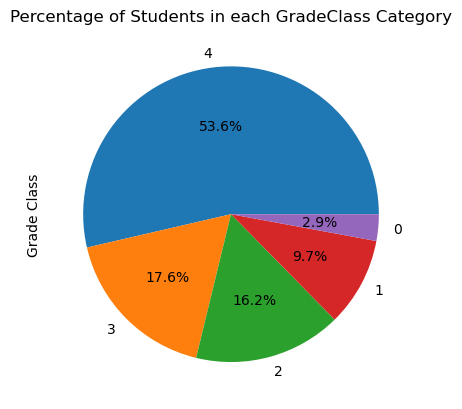

In [15]:
import matplotlib.pyplot as plt
plt.pie(students['GradeClass'].value_counts(), labels = students['GradeClass'].value_counts().index, autopct='%1.1f%%')
plt.title("Percentage of Students in each GradeClass Category")
plt.ylabel("Grade Class")
plt.show()

# Referred to 
# https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

Description:
This pie chart shows the percentage of students in each GradeClass category, where labels 0,1,2,3,4 corresponds to GradeClass.
The pie chart percentages match the percentages calculated in A2.1. There are small differences due to the rounding to one decimal place in the pie chart labels.

--- A2 Task 3 ---

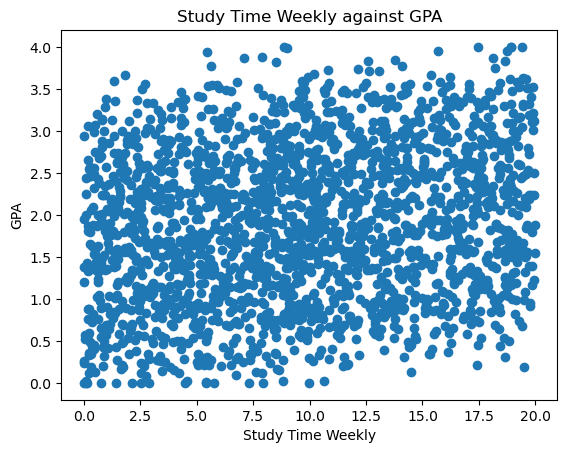

In [16]:
plt.scatter(students['StudyTimeWeekly'], students['GPA'])
plt.title('Study Time Weekly against GPA')
plt.xlabel('Study Time Weekly')
plt.ylabel('GPA')
plt.show()
# Independent variable = StudyTimeWeekly
# Dependent variable = GPA

In [17]:
# Analyse statistical values
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(students.StudyTimeWeekly,students.GPA)
print("Slope: %f   intercept: %f" % (slope, intercept)) 
print("r-value: %f" % r_value)
print("p-value: %f" % p_value)


Slope: 0.028856   intercept: 1.612523
r-value: 0.179058
p-value: 0.000000


The correlation (r_value) is 0.179, indicating a very weak positive correlation between the independent variable (StudyTimeWeekly) and the dependent variable (GPA).
This weak positive correlation suggests that when the StudyTimeWeekly variable increases, the GPA of the students will be slightly higher on average, but their relationship is weak. There may be many students with low study times who have high GPAs and vice versa, which indicates that StudyTimeWeekly may not be strongly associated with academic performance.

--- A2 Task 4 ---

The feature used to show the relationship with GPA is Absences, as students' participation in class could affect their understanding, which is directly related to their results (GPA).

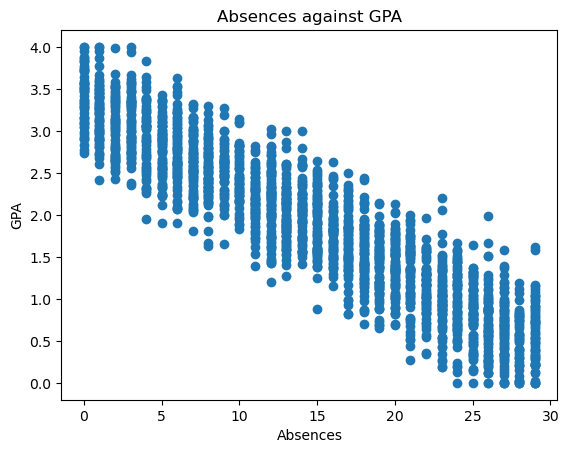

Slope: -0.099046   intercept: 3.340619
r-value: -0.919779
p-value: 0.000000


In [18]:
# Independent variable = Absences
# Dependent variable = GPA
plt.scatter(students.Absences, students.GPA)
plt.title("Absences against GPA")
plt.xlabel('Absences')
plt.ylabel('GPA')
plt.show()
slope, intercept, r_value, p_value, std_err = linregress(students.Absences,students.GPA)
print("Slope: %f   intercept: %f" % (slope, intercept)) 
print("r-value: %f" % r_value)
print("p-value: %f" % p_value)

The correlation (r_value) is -0.92, indicating a strong negative correlation between the independent variable (Absences) and the dependent variable (GPA).
This suggests that students with more absences tend to have lower GPAs in this dataset, which aligns with the behavioural pattern that missing class may affect academic performance. Students with more absences might miss key points in lectures, discussions or in-class activities, reducing understanding and resulting in a lower GPA.

--- A2 Task 5 ---

Correlation alone is not sufficient to conclude causation in this dataset. This is because correlation only measures the strength of association or suggests a relationship, but does not explain the reason for 2 variables move together or which one causes the other.
For instance, even though StudyTimeWeekly shows a positive correlation with GPA, this does not mean that increasing study time will always cause a higher GPA, as other factors, such as participation or teaching quality, may influence both the variables.
To strengthen the causation, additional data such as the learning environment and prior academic performance would be needed to help clarify the connection between GPA and StudyTimeWeekly or Absences.

--- A2 Task 6 ---

In [19]:
# Get the mean, median, standard deviation, and IQR of GPA and Absences, grouping by GradeClass
func = ['mean','median','std', lambda x: x.quantile(0.75) - x.quantile(0.25) ]
aggregation_gradeclass = students.groupby('GradeClass')[['GPA','Absences']].agg(func)
aggregation_gradeclass.rename(
    columns = {'<lambda_0>' : 'IQR'},
    inplace = True
)
aggregation_gradeclass
# Referred to:
# https://www.geeksforgeeks.org/python/python-lambda-anonymous-functions-filter-map-reduce/

GPA                                 Absences         \
                mean    median       std       IQR       mean median   
GradeClass                                                             
0           3.681490  3.618273  0.163589  0.275281   1.475410    1.0   
1           3.227285  3.219432  0.143109  0.242832   3.308824    3.0   
2           2.732964  2.723828  0.145818  0.250655   6.433628    6.0   
3           2.249837  2.240924  0.137388  0.230745  11.140921   11.0   
4           1.181513  1.234141  0.513394  0.788061  21.008000   21.0   

                           
                 std  IQR  
GradeClass                 
0           1.659383  3.0  
1           2.500782  4.0  
2           3.562318  5.0  
3           3.783787  6.0  
4           5.033246  8.0

--- A2 Task 7 ---

In [20]:
aggregation_gradeclass = aggregation_gradeclass.reset_index()
aggregation_gradeclass.columns = aggregation_gradeclass.columns.droplevel(0)
aggregation_gradeclass.columns = ['GradeClass','GPA_mean','GPA_median','GPA_std','GPA_IQR',
                                  'Absences_mean','Absences_median','Absences_std','Absences_IQR']
aggregation_gradeclass

,GradeClass,GPA_mean,GPA_median,GPA_std,GPA_IQR,Absences_mean,Absences_median,Absences_std,Absences_IQR
0,0,3.681490,3.618273,0.163589,0.275281,1.475410,1.0,1.659383,3.0
1,1,3.227285,3.219432,0.143109,0.242832,3.308824,3.0,2.500782,4.0
2,2,2.732964,2.723828,0.145818,0.250655,6.433628,6.0,3.562318,5.0
3,3,2.249837,2.240924,0.137388,0.230745,11.140921,11.0,3.783787,6.0
4,4,1.181513,1.234141,0.513394,0.788061,21.008000,21.0,5.033246,8.0


**A3. Supervised Learning**

--- A3 Task 1 ---

Supervised Machine Learning is a learning style in ML algorithms where models is trained using labelled data to predict the output from the input data.
Training is the process for a model to learn to recognise patterns from training data and apply them for predictions. 
While testing is to examine how well the model can generalise or predict the labels for testing data that was not used in training.
One risk of not holding a test set is that the model may function accurately on training data but fail on new data due to lack of proper evaluation.

--- A3 Task 2 ---

In [21]:
print("Features Kept/Excluded for GradeClass prediction: ")
feature_table = pd.DataFrame(
    {'Columns': students.columns,
     'Keep/Exclude': ['Exclude', 'Keep', 'Keep','Keep','Keep', 'Exclude', 'Label']
    }
)

feature_table

Features Kept/Excluded for GradeClass prediction: 


,Columns,Keep/Exclude
0,StudentID,Exclude
1,Age,Keep
2,StudyTimeWeekly,Keep
3,Absences,Keep
4,ParentalSupport,Keep
5,GPA,Exclude
6,GradeClass,Label


StudentID is excluded because it serves as the students' identifier, which does not describe student behaviour or affect their grade.
Age and ParentalSupport are kept as they provide contextual information and may influence students' behavioural patterns.
StudyTimeWeekly and Absences are retained as they are direct behavioural features, which are likely related to academic performance.
GPA is excluded because it overlaps with the target variable GradeClass, as GradeClass is derived from GPA cut-offs.


--- A3 Task 3 ---

In [22]:
from sklearn.model_selection import train_test_split

x = students.iloc[:,[1,2,3,4]].values # Input data: Age, StudyTimeWeekly, Absences, ParentalSupport
y = students.iloc[:, 6].values        # Labeled Data = GradeClass
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 95
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (1468, 4)
Testing features: (630, 4)
Training labels: (1468,)
Testing labels: (630,)


Based on my understanding, I would not use 70/30 for a very small dataset splitting. This is because the 70% of training set would be too few for the model to learn patterns. Thus, a larger proportion of data could be distributed to training, such as 80/20 or 90/10, which could improve the model's learning and still keep a small portion for testing.

**A4. Classification (training)**

--- A4 Task 1 ---

1. The distance between points that are made up of data feature values is significant in machine learning algorithms, such that the range of data features could directly contribute to the final distance. Thus, if one of the features has a wide range of values, it will dominate the distance without normalisation. Normalisation is necessary in this kind of situation, which will scale the features' range so they can contribute in a more balanced way or proportionally to the final distance.

In [23]:
# Feature pair chosen: Absences and Age
print(students[['Age','Absences']].describe())

               Age     Absences
count  2098.000000  2098.000000
mean     16.476168    14.628694
std       1.124850     8.434995
min      15.000000     0.000000
25%      15.000000     7.000000
50%      16.000000    15.000000
75%      17.000000    22.000000
max      18.000000    29.000000


From the above statistic on the features Age and Absences, it can be observed that the data values range for Age (15-18) and Absences (0-29) differ significantly. If these features are not scaled, the differences in Absences will produce much larger distance values, causing the model to be influenced more by them when making predictions, even though Age is also important.

In [24]:
# 2. Scaling training data
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Columns scaled are Age, StudyTimeWeekly, Absences and ParentalSupport.
GPA is removed because GradeClass is derived from GPA using the defined cut-offs. Including GPA as a training feature will cause the model to directly gain the information of the target class instead of learning the patterns from other features independently.

--- A4 Task 2 ---

1. SVM (Support Vector Machine) is a supervised machine learning algorithm used for classification, regression, and outlier detection. It functions by finding the best boundary, known as a hyperplane to separate the classes in the data, particularly useful for binary and multi-class classification. The main goal of SVM is to find the maximum margin using the support vectors, because the larger the margin, the better the generalisation of the classifier. The margin is the distance from the hyperplane to the support vectors. Support vectors are the sample points nearest to the boundary, these points are important because they can determine where the margin boundaries are placed.

2. When the data is not linearly separable, which means it cannot be classified using straight lines, a normal linear boundary fails. Thus, a kernel function is used to map data into a higher-dimensional space to make the data separable. The kernel is important to transform non-linear data into a separable dimensional space to help SVM find the boundary for them. Additionally, kernels like the Radial Basis Function (RBF) can find complex and non-linear boundaries, while a linear kernel is simpler and tries to find a straight-line boundary in the original space. It allows the SVM to find a hyperplane in the new higher-dimensional space and handle non-linearly separable data effectively.

Referred to:
https://scikit-learn.org/stable/modules/svm.html
https://www.geeksforgeeks.org/machine-learning/support-vector-machine-algorithm/

In [25]:
# 3. Build a predictive SVM model with the dataset
# The features included are StudyTimeWeekly, Absences, and ParentalSupport

from sklearn import svm
# Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

# Train the model using the training sets
clf.fit(X_train, y_train)

# Referred to:
# https://www.datacamp.com/tutorial/svm-classification-scikit-learn-python

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


StudentID is removed from the training data because it is only a unique identifier for each student and does not contribute to meaningful pattern for prediction. GPA is excluded because GradeClass is directly derived from GPA ranges as mentioned earlier.
While other features are chosen as they may provide useful behavioural and contextual information related to academic performance.

--- A4 Task 3 ---

In [26]:
# Other Classifier: Random Forest Algorithm
# Fitting Random Forest Classification to the Training set
from sklearn.ensemble import RandomForestClassifier

x = students.iloc[:,[1,2,3,4]].values # Input data: Age, StudyTimeWeekly, Absences, ParentalSupport
y = students.iloc[:, 6].values        # Labeled Data = GradeClass
X_train_RF, X_test_RF, y_train_RF, y_test_RF = train_test_split(
    x, y, test_size = 0.3, random_state = 95
)

classifier = RandomForestClassifier(
 n_estimators = 100,
 criterion = 'entropy',
 random_state = 95
)

classifier.fit(X_train_RF, y_train_RF)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**A5. Classification (prediction)**

--- A5 Task 1 ---

In [27]:
# Prediction for the GradeClass
# Prediction on Training Data
y_train_pred_svm = clf.predict(X_train)           # Prediction by SVM model
y_train_pred_rf = classifier.predict(X_train_RF)  # Prediction by Random Forest Algorithm

# Prediction on Testing Data
y_pred_svm = clf.predict(X_test)          # Prediction by SVM model
y_pred_rf = classifier.predict(X_test_RF) # Prediction by Random Forest Algorithm

--- A5 Task 2 ---

Confusion Matrix for SVM Model:


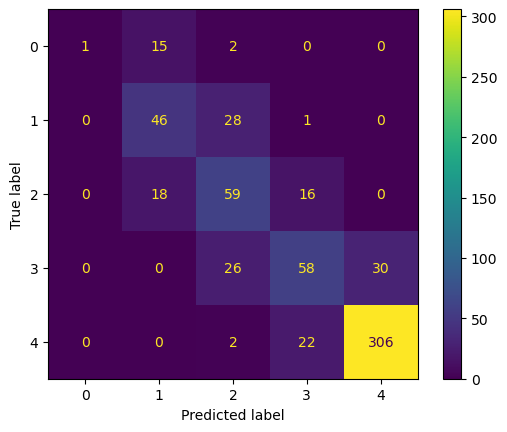

Confusion Matrix for Random Forest Algorithm Model:


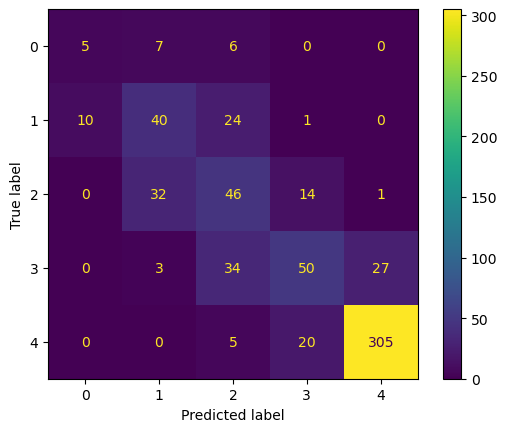

Accuracy of SVM model (Training data): 0.7731607629427792
Accuracy of Random Forest Algorithm model (Training data): 1.0

Accuracy of SVM model (Testing data): 0.746031746031746
Accuracy of Random Forest Algorithm model (Testing data): 0.707936507936508


In [28]:
# Making the Confusion Matrix
from sklearn import metrics
from sklearn.metrics import confusion_matrix
cm_SVM = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix for SVM Model:")
cm_SVM_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_SVM, display_labels = [0,1,2,3,4])
cm_SVM_display.plot()
plt.show()

cm_RF = confusion_matrix(y_test_RF, y_pred_rf)
print("Confusion Matrix for Random Forest Algorithm Model:")
cm_RF_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_RF, display_labels = [0,1,2,3,4])
cm_RF_display.plot()
plt.show()

# Accuracy Calculation
print("Accuracy of SVM model (Training data):",metrics.accuracy_score(y_train, y_train_pred_svm))
print("Accuracy of Random Forest Algorithm model (Training data):",metrics.accuracy_score(y_train_RF, y_train_pred_rf))
print()
print("Accuracy of SVM model (Testing data):",metrics.accuracy_score(y_test, y_pred_svm))
print("Accuracy of Random Forest Algorithm model (Testing data):",metrics.accuracy_score(y_test_RF, y_pred_rf))

# Referred to:
# https://www.w3schools.com/python/python_ml_confusion_matrix.asp

From the confusion matrices of both models, it can be observed that the biggest confusion pair is between GradeClass 3 <-> 4, which is D <-> F. The SVM model incorrectly identified many GradeClass D students as GradeClass F, and vice versa. 
This may occur because the students within these grade categories often share similar behavioural patterns, such as similar study time, absence frequency and parental support. Since these students demonstrate very similar characteristics, the classification will be more difficult for students who are near the boundary between 2 GradeClass categories.

--- A5 Task 3 ---

The prediction performance of the SVM model (74.60%) is better compared to the Random Forest Algorithm (RF) model (70.48%).
One possible reason for SVM to perform better is that the dataset may be more suitable to be separated using the linear boundary classification produced by SVM. The input features were normalised before training, which enabled SVM to calculate distance and boundaries more effectively. Conversely, the RF model may have learned more complex patterns and noise from the data, which may have limited its ability to generalise.

--- A5 Task 4 ---

Based on the accuracy calculation on the training data and testing data of both models,  the SVM model is more likely to exhibit slightly higher bias but low variance, while the RF model is more likely to exhibit higher variance and strong signs of overfitting.

This can be determined by the similar moderate accuracy (77.38% vs 74.6%) calculated on both datasets on the SVM model, which indicates lower variance, and its moderate accuracy suggests that a slight bias exists. This is likely because the linear kernel used in the model creates a simpler boundary, which may not fully recognise all details within the dataset.
As for the RF model, it has extremely high train accuracy (100%) but a noticeably lower test accuracy (70.47%), which indicates higher variance as an overfitting sign. Overfitting refers to the model focusing too much on the training data and capturing random noise, which can be observed by high training accuracy with low testing accuracy.

The overall outcome of these models indicates that this dataset with 4 features is best modelled by a simple linear SVM model. 
Referred to:
https://medium.com/@duygujones/understanding-the-bias-variance-tradeoff-in-machine-learning-b933266d7e08